# Aula 5 - Alguns gráficos com Pandas

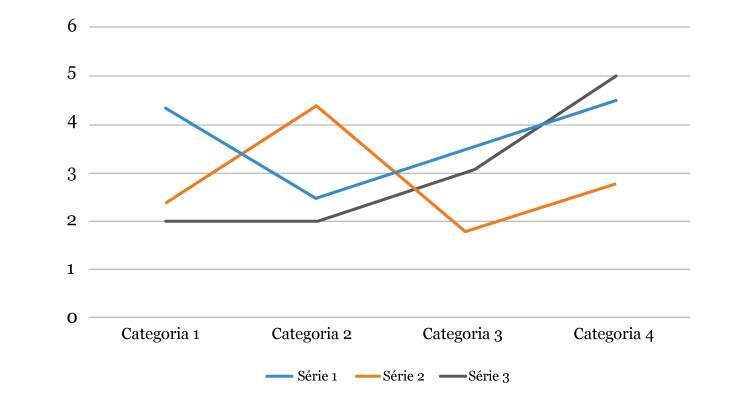### Introdução

Gráficos são representações visuais dos dados, que buscam facilitar o entendimento dos mesmos. Podem ser muito úteis na identificação de variáveis importantes para uma modelagem ou tomada de decisão.


**Tipos de gráficos mais usuais:**
- **Scatter plot (ou gráfico de dispersão):**
Dadas duas variáveis X e Y, cada observação (par de valores (x,y)) é representado por um ponto no gráfico. Na imagem abaixo, uma observação (x,y) = (4,5) é representada pelo X vermelho.
<img src="images/img_scatterplot_editada.png" alt="Drawing" style="width: 500px;"/>

- **Gráfico de linhas:**
O gráfico de linhas é muito utilizado quando estamos querendo encontrar tendências de um conjunto de variáveis. No geral, a variável alocada no eixo horizontal representa categorias ordinais, geralmente temporais (como por exemplo: meses, anos, dias, semanas, lotes em ordem de fabricação etc). Para construí-lo, primeiro aplica-se um gráfico de dispersão dessas variáveis, e depois unem-se os pontos por linhas, como mostra a imagem abaixo. Podemos imaginar que cada categoria é um lote de produção de uma mercadoria (em que o lote 1 foi produzido antes do lote 2, e assim por diante), e no eixo vertical, têm se a quantidade vendida de cada lote. Ainda, há 3 séries representadas por cores, que podem representar, por exemplo, três clientes diferentes que adquiriram as mercadorias.
<img src="./images/grafico_linhas.jpg" alt="Drawing" style="width: 500px;"/>

- **Gráfico de pizza/Pie plot (ou gráfico de setores):**
Este gráfico tem como objetivo representar um valor relativo de cada categoria em relação a um todo. Exemplo: de todo o lucro de uma empresa revendedora de aparelhos celular, quantos porcento são relativos a cada marca de produto comercializado.
<img src="./images/grafico_pizza.png" alt="Drawing" style="width: 400px;"/>

- **Gráfico de barras (horizontal e vertical):**
Um gráfico de barras é uma forma de visualização de dados categóricos, em que cada categoria é representada por uma barra, cujo tamanho representa sua frequência/quantidade de observações. Pode ser representado de forma vertical (conhecido também como gráfico de colunas) ou de forma horizontal (em que o gráfico parece "deitado". No exemplo abaixo, o mesmo conjunto de dados é representado das duas formas. 

Observação: Aqui, os valores "1", "2" e "3" das barras representam categorias, e não uma variável contínua.
<img src="./images/grafico_barras.png" alt="Drawing" style="width: 500px;"/>

- **Histograma:** 
Um histograma é muito parecido com um gráfico de barras, e possui a mesma ideia: cada coluna representa uma frequência/quantidade. Entretanto, o eixo horizontal deste tipo de gráfico é uma variável contínua, e a ideia é observar a distribuição das observações desta variável. Exemplos de perguntas que podemos estar tentando responder ao analisar esse tipo de gráfico, são: "quais são os valores mais frequentes nessa variável contínua?" e "Qual a probabilidade de uma nova observação ter determinado valor?"

Para se construir as barras deste gráfico, a variável contínua é agrupada em intervalos, e o tamanho da barra representa o número de observações que possuem valores dentro deste intervalo. É comum encontrar histogramas com um traço linear ligando o topo dessas barras pelo meio, de forma a facilitar a identificação de uma distribuição estatística.
<img src="./images/histograma.png" alt="Drawing" style="width: 500px;"/>

- **Box-Plot:**
Os box-plot, assim como os histogramas, são gráficos estatísticos que permitem analisar uma distribuição dos dados, mas com uma representação diferente. Apesar de muito utilizados por estatísticos e cientistas de dados, a maioria das pessoas que não estão acostumadas a eles, têm dificuldade em interpretá-los. 

A representação do box-plot se baseia em medidas de quartis: uma caixinha central é desenhada ligando o primeiro (Q1) e terceiro (Q3) quartis (25% e 75%, respectivamente), e uma reta corta essa 'caixa' no quartil central (Q2 = 50%). Na parte inferior e superior do gráfico, é traçada uma reta de tamanho máximo 1.5xIQ, em que IQ = Q3-Q1. Essa reta é traçada até o último valor da variável que ainda esteja dentro desse limite. Observações acima ou abaixo dele, são representadas por bolinhas, e muito chamadas de 'outliers' (valor atípico). Abaixo, uma representação dos componentes de um box-plot, e um gráfico exibindo box-plots das distribuições de temperaturas de diferentes cidades.
<img src="./images/boxplot2.png" alt="Drawing" style="width: 500px;"/>
<img src="./images/boxplot.png" alt="Drawing" style="width: 500px;"/>

## Gráficos com pandas

A biblioteca pandas, que estudamos no módulo passado, permite realizar alguns gráficos simples, baseados na biblioteca matplotlib. Vamos aprender a aplicá-los utilizando a base de dados das medições dos pinguins como exemplo.  

**Documentação:** https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns 

df_size = sns.load_dataset("penguins")
print(df_size.shape)

In [16]:
df_size.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [17]:
df_size.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


<img src="./images/bill_depth.png" alt="Drawing" style="width: 350px;"/>
<img src="./images/fliper_lenght.jpg" alt="Drawing" style="width: 250px;"/>

### Gráfico de dispersão (scatter plot)

<AxesSubplot:xlabel='bill_length_mm', ylabel='bill_depth_mm'>

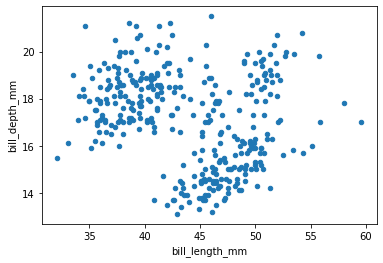

In [18]:
df_size.plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter')

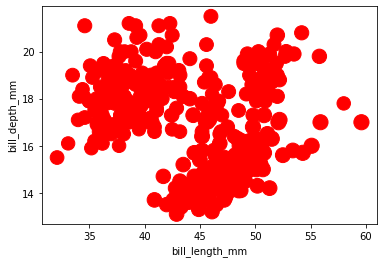

In [19]:
df_size.plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', s = 'flipper_length_mm', c = 'red');

#### Criando gráficos com filtros

In [20]:
df_size[df_size['sex'] == 'FEMALE'].head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,FEMALE
12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,FEMALE


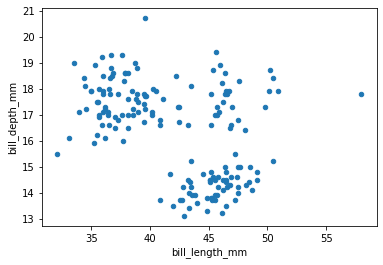

In [21]:
df_size[df_size['sex'] == 'FEMALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter');

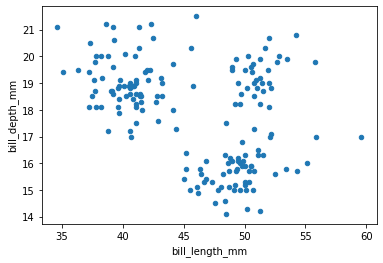

In [22]:
df_size[df_size['sex'] == 'MALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter');

#### Unindo dois gráficos

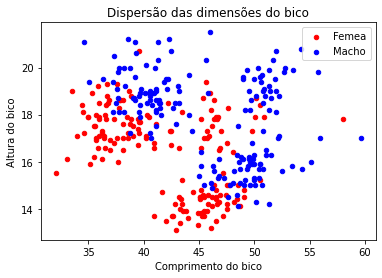

In [23]:
ax1 = df_size[df_size.sex == 'FEMALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'red',
                                           label='Femea', title='Dispersão das dimensões do bico')
ax2 = df_size[df_size.sex == 'MALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'blue', ax=ax1,
                                         label='Macho', xlabel='Comprimento do bico', ylabel='Altura do bico')

#### Ajustando os labels

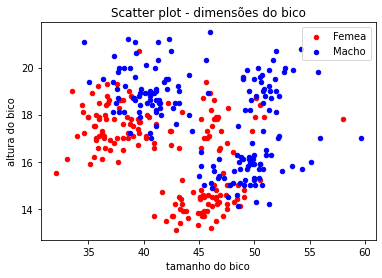

In [24]:
ax1 = df_size[df_size.sex == 'FEMALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'red', label = 'Femea', )
ax2 = df_size[df_size.sex == 'MALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'blue', label = 'Macho', 
                                ax=ax1)

ax1.set_xlabel('tamanho do bico')
ax1.set_ylabel('altura do bico')
ax1.set_title('Scatter plot - dimensões do bico');

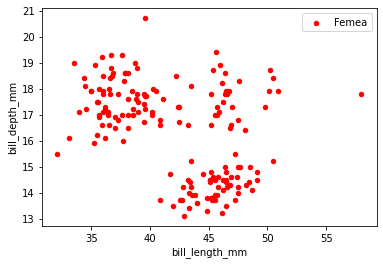

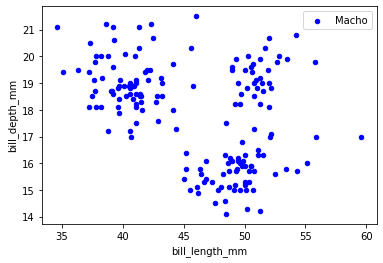

In [25]:
df_size[df_size.sex == 'FEMALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'red', label = 'Femea')
df_size[df_size.sex == 'MALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'blue', label = 'Macho');

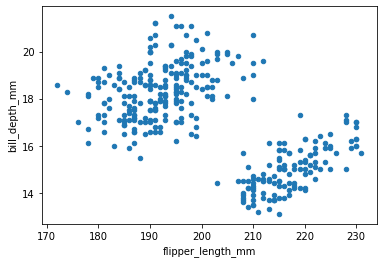

In [26]:
df_size.plot(x='flipper_length_mm', y='bill_depth_mm', kind='scatter');

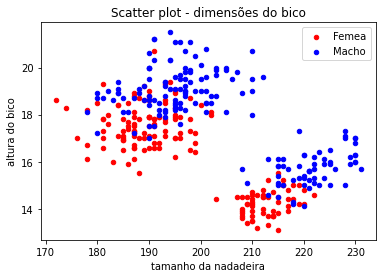

In [27]:
ax1 = df_size[df_size.sex == 'FEMALE'].plot(x='flipper_length_mm', y='bill_depth_mm', kind='scatter', c = 'red', label = 'Femea', )
ax2 = df_size[df_size.sex == 'MALE'].plot(x='flipper_length_mm', y='bill_depth_mm', kind='scatter', c = 'blue', label = 'Macho', 
                                ax=ax1)

ax1.set_xlabel('tamanho da nadadeira')
ax1.set_ylabel('altura do bico')
ax1.set_title('Scatter plot - dimensões do bico');

#### Tamanho do gráfico

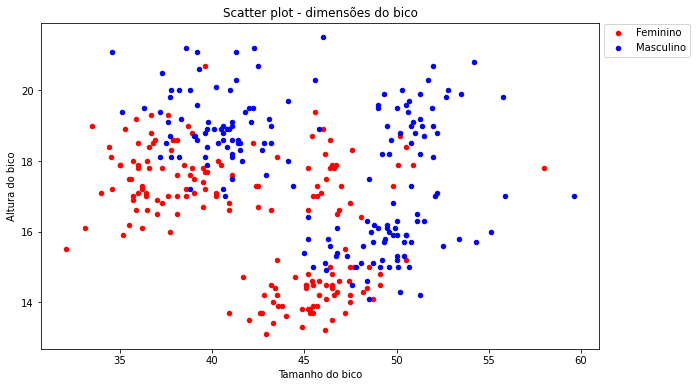

In [28]:
ax1 = df_size[df_size.sex == 'FEMALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'red', label = 'Feminino', figsize=(10,6))
ax2 = df_size[df_size.sex == 'MALE'].plot(x='bill_length_mm', y='bill_depth_mm', kind='scatter', c = 'blue', label = 'Masculino', 
                                ax=ax1)


ax1.set_xlabel('Tamanho do bico')
ax1.set_ylabel('Altura do bico')
ax1.set_title('Scatter plot - dimensões do bico')
ax1.legend(loc='lower left', bbox_to_anchor = (1.0, 0.88));

## Gráfico de linhas

In [29]:
df_vendas = pd.DataFrame({'Mês' : ['Jan', 'Fev', 'Mar', 'Abr', 'Jan', 'Fev', 'Mar', 'Abr', 'Jan', 'Fev', 'Mar', 'Abr'],
                         'Quantidade' : np.random.randint(low=100, size=12),
                          'Veículo' : np.repeat(['HB20', 'Onix', 'Sandero'],4)})
df_vendas

,Mês,Quantidade,Veículo
0,Jan,2,HB20
1,Fev,31,HB20
2,Mar,11,HB20
3,Abr,71,HB20
4,Jan,18,Onix
5,Fev,55,Onix
6,Mar,61,Onix
7,Abr,0,Onix
8,Jan,51,Sandero
9,Fev,92,Sandero


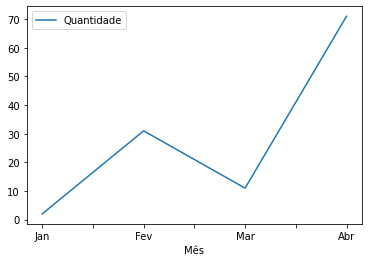

In [30]:
df_vendas[df_vendas['Veículo'] == 'HB20'].plot(x='Mês', y='Quantidade');

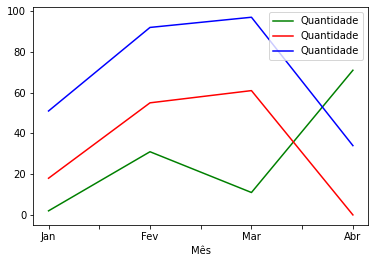

In [31]:
ax1 = df_vendas[df_vendas['Veículo'] == 'HB20'].plot(x='Mês', y='Quantidade', c='green')
ax2 = df_vendas[df_vendas['Veículo'] == 'Onix'].plot(x='Mês', y='Quantidade', c='red', ax=ax1)
ax3 = df_vendas[df_vendas['Veículo'] == 'Sandero'].plot(x='Mês', y='Quantidade', c='blue', ax=ax1)

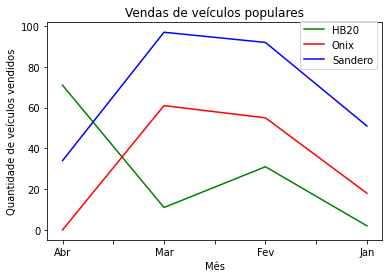

In [32]:
ax1 = df_vendas[df_vendas['Veículo'] == 'HB20'].plot(x='Mês', y='Quantidade', c='green', label = 'HB20')
ax2 = df_vendas[df_vendas['Veículo'] == 'Onix'].plot(x='Mês', y='Quantidade', c='red', ax=ax1, label = 'Onix')
ax3 = df_vendas[df_vendas['Veículo'] == 'Sandero'].plot(x='Mês', y='Quantidade', c='blue', ax=ax2, label = 'Sandero')

ax1.invert_xaxis()
ax1.set_ylabel('Quantidade de veículos vendidos')
ax1.set_title('Vendas de veículos populares')
ax1.legend(bbox_to_anchor = (1.0, 1.03));

In [62]:
df_vendas

,Mês,Quantidade,Veículo
0,Jan,2,HB20
1,Fev,31,HB20
2,Mar,11,HB20
3,Abr,71,HB20
4,Jan,18,Onix
5,Fev,55,Onix
6,Mar,61,Onix
7,Abr,0,Onix
8,Jan,51,Sandero
9,Fev,92,Sandero


In [64]:
df_vendas.pivot_table(index = "Mês", columns = "Veículo", values = "Quantidade")

Veículo,HB20,Onix,Sandero
Mês,,,
Jan,2,18,51
Fev,31,55,92
Mar,11,61,97
Abr,71,0,34


In [33]:
df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade')

Veículo,HB20,Onix,Sandero
Mês,,,
Abr,71,0,34
Fev,31,55,92
Jan,2,18,51
Mar,11,61,97


In [73]:
pd.crosstab(index = df_vendas["Mês"], columns = df_vendas["Veículo"], values = df_vendas["Quantidade"], aggfunc = "mean")

Veículo,HB20,Onix,Sandero
Mês,,,
Jan,2,18,51
Fev,31,55,92
Mar,11,61,97
Abr,71,0,34


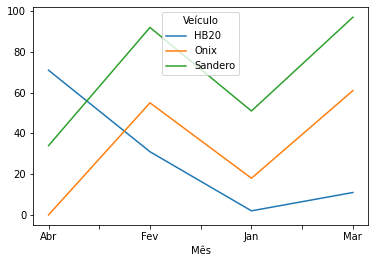

In [34]:
df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade').plot(kind='line');

In [35]:
df_vendas['Mês'] = pd.Categorical(df_vendas['Mês'], categories=["Jan", "Fev", "Mar", "Abr"], ordered=True)
df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade')

Veículo,HB20,Onix,Sandero
Mês,,,
Jan,2,18,51
Fev,31,55,92
Mar,11,61,97
Abr,71,0,34


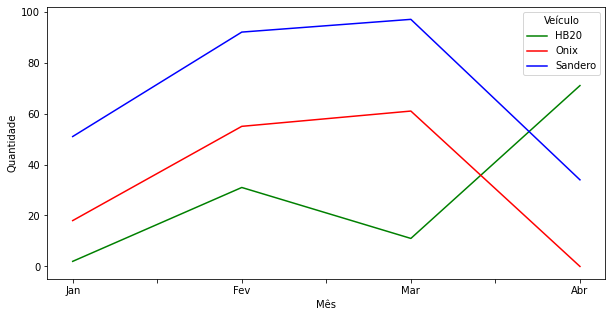

In [36]:
df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade').plot(kind='line', ylabel='Quantidade', figsize=(10,5), color={'Onix': 'red', 'Sandero': 'blue', 'HB20': 'green'});

Inverter o eixo X

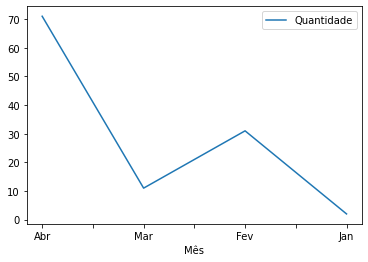

In [37]:
df_vendas[df_vendas['Veículo'] == 'HB20'].plot(x='Mês', y='Quantidade').invert_xaxis()

## Gráfico de pizza

In [38]:
df_vendas.groupby(['Veículo']).sum()

,Quantidade
Veículo,
HB20,115
Onix,134
Sandero,274


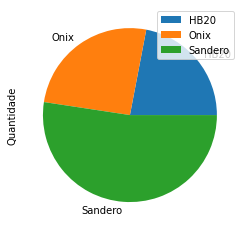

In [77]:
df_vendas.groupby(['Veículo'])["Quantidade"].sum().plot(kind='pie', legend = True);

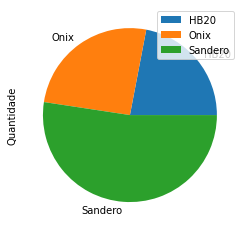

In [74]:
df_vendas.groupby(['Veículo']).sum().plot(y='Quantidade', kind='pie');

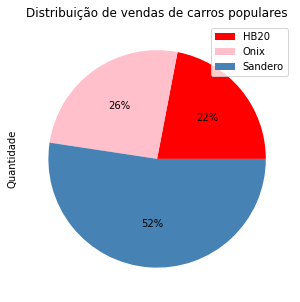

In [40]:
df_vendas.groupby(['Veículo']).sum().plot(y='Quantidade', kind='pie', autopct='%1.0f%%',
                                colors = ['red', 'pink', 'steelblue'], figsize=(10,5), labeldistance=None,
                                         title='Distribuição de vendas de carros populares');

In [41]:
df_vendas.pivot_table(index='Veículo', values='Quantidade', aggfunc='sum')

,Quantidade
Veículo,
HB20,115
Onix,134
Sandero,274


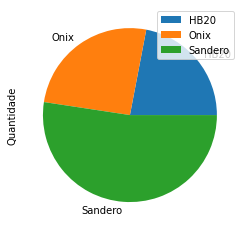

In [42]:
df_vendas.pivot_table(index='Veículo', values='Quantidade', aggfunc='sum').plot(y='Quantidade', kind='pie');

In [43]:
df_vendas.pivot_table(index='Mês', values='Quantidade', aggfunc='sum')

,Quantidade
Mês,
Jan,71
Fev,178
Mar,169
Abr,105


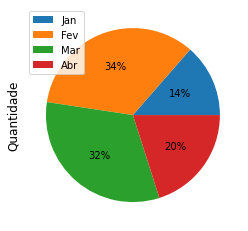

In [44]:
ax = df_vendas.pivot_table(index='Mês', values='Quantidade', aggfunc='sum').plot(y='Quantidade', kind='pie', autopct='%1.0f%%', fontsize=10, labeldistance=None)

ax.set_ylabel('Quantidade', fontsize=12);

In [45]:
df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade')

Veículo,HB20,Onix,Sandero
Mês,,,
Jan,2,18,51
Fev,31,55,92
Mar,11,61,97
Abr,71,0,34


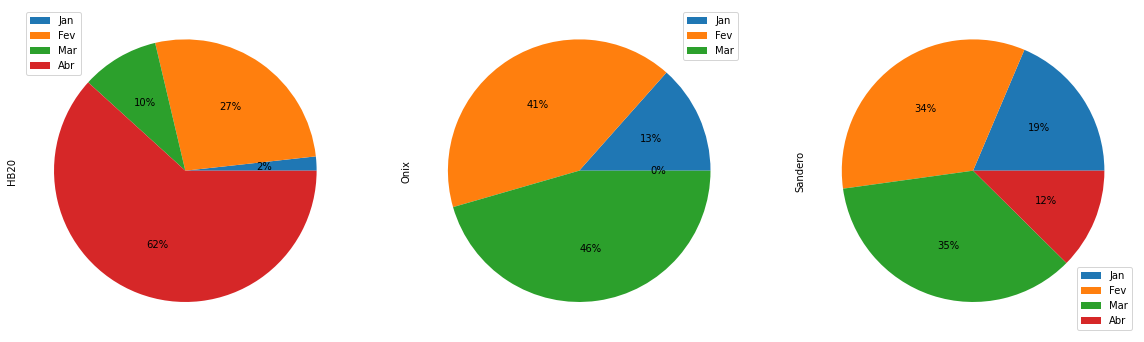

In [46]:
df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade').plot(subplots=True, kind='pie', figsize=(20,10), 
                                                                      autopct='%1.0f%%', labeldistance=None);

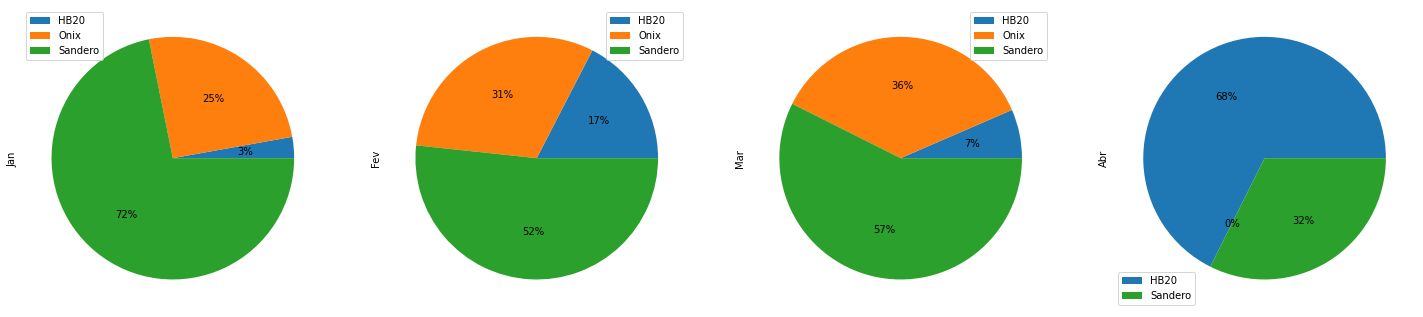

In [47]:
df_vendas.pivot(index='Veículo', columns='Mês', values='Quantidade').plot(subplots=True, kind='pie', figsize=(25,20), 
                                                                      autopct='%1.0f%%', fontsize=10, labeldistance=None);

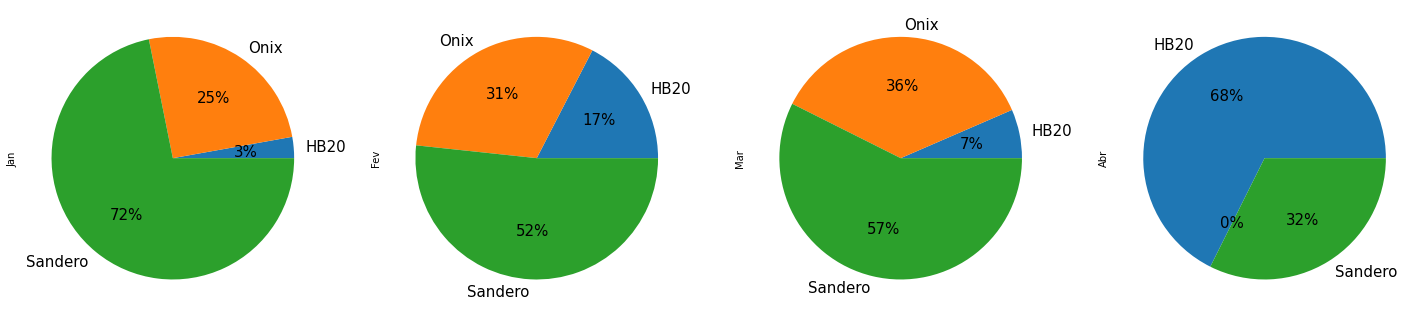

In [48]:
df_vendas.pivot(index='Veículo', columns='Mês', values='Quantidade').plot(subplots=True, kind='pie', figsize=(25,20), 
                                                                      autopct='%1.0f%%', fontsize=15, legend=None);

## Gráfico de barras

In [49]:
df_vendas.groupby('Veículo').sum()

,Quantidade
Veículo,
HB20,115
Onix,134
Sandero,274


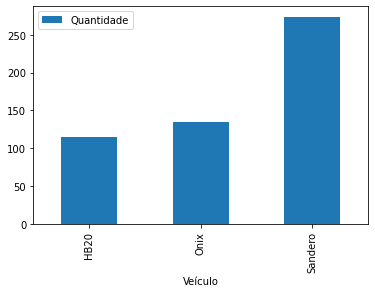

In [50]:
df_vendas.groupby('Veículo').sum().plot(kind='bar');

In [51]:
df_vendas.groupby('Mês').sum()

,Quantidade
Mês,
Jan,71
Fev,178
Mar,169
Abr,105


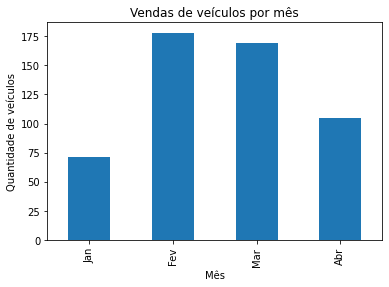

In [52]:
df_vendas.groupby('Mês').sum().plot(kind='bar', title='Vendas de veículos por mês', legend=None, ylabel='Quantidade de veículos');

#### Subplots

In [79]:
df_vendas_pivot = df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade')
df_vendas_pivot

Veículo,HB20,Onix,Sandero
Mês,,,
Jan,2,18,51
Fev,31,55,92
Mar,11,61,97
Abr,71,0,34


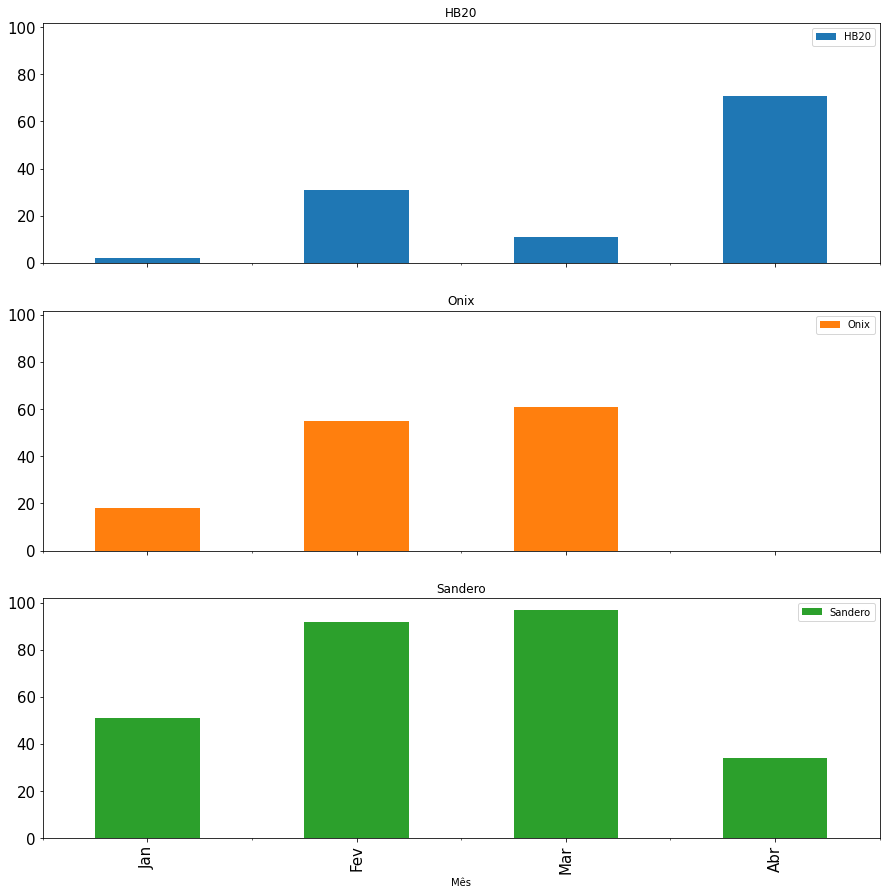

In [84]:
ax_bar = df_vendas_pivot.plot(
    subplots=True, 
    kind='bar', 
    figsize=(15,15), 
    fontsize=15, 
    sharey=True);

#### Multiplotagem

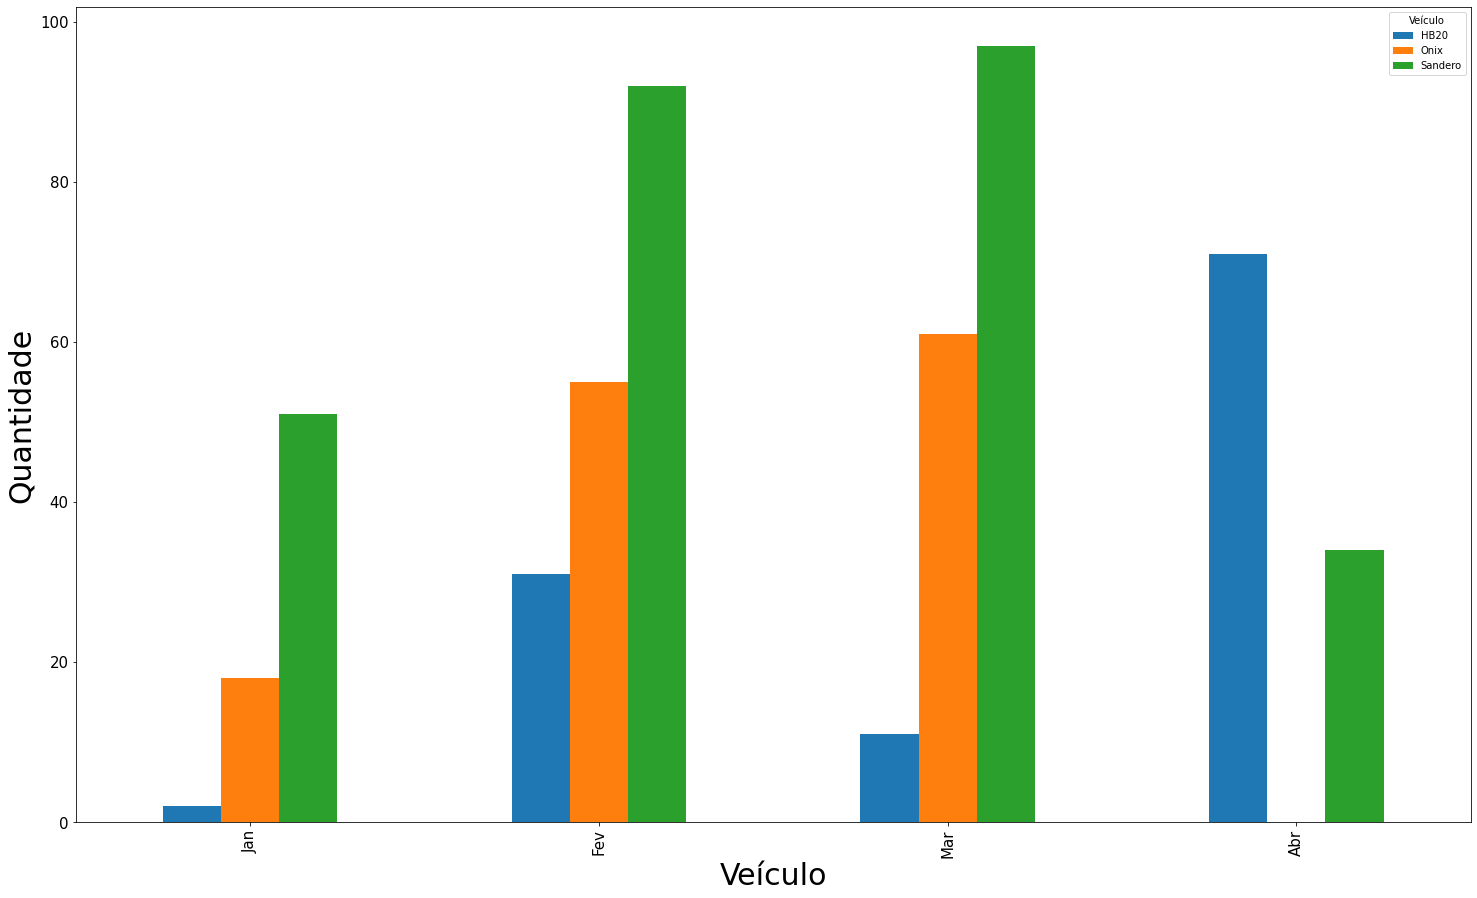

In [55]:
ax_bar = df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade').plot(kind='bar', figsize=(25,15), 
                                                                      fontsize=15)

ax_bar.set_ylabel('Quantidade', fontsize=30)
ax_bar.set_xlabel('Veículo', fontsize=30);

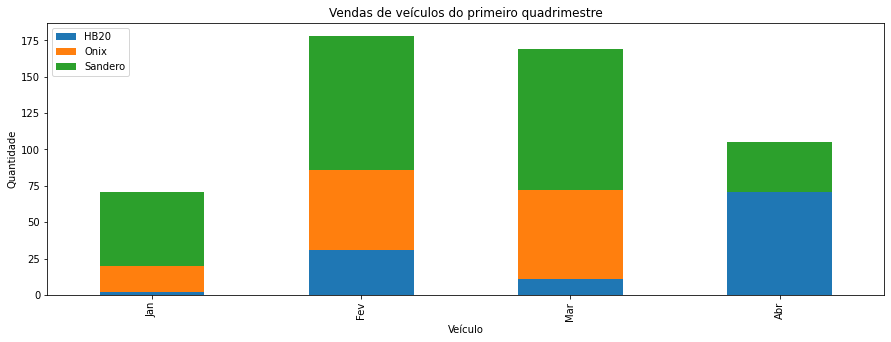

In [56]:
ax_bar = df_vendas.pivot(index='Mês', columns='Veículo', values='Quantidade').plot(kind='bar', figsize=(15,5), 
                                                                      stacked=True, title = 'Vendas de veículos do primeiro quadrimestre')

ax_bar.set_ylabel('Quantidade', fontsize=10)
ax_bar.set_xlabel('Veículo')
ax_bar.legend(loc='upper left', fontsize=10);

In [57]:
pd.crosstab(index=df_vendas['Mês'], columns=df_vendas['Veículo'],values=df_vendas['Quantidade'], aggfunc='sum', normalize='index')

Veículo,HB20,Onix,Sandero
Mês,,,
Jan,0.028169,0.253521,0.718310
Fev,0.174157,0.308989,0.516854
Mar,0.065089,0.360947,0.573964
Abr,0.676190,0.000000,0.323810


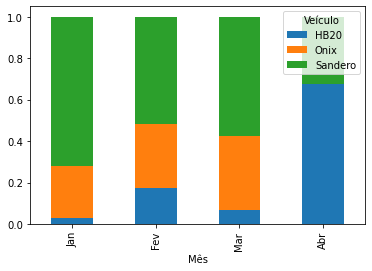

In [58]:
pd.crosstab(index=df_vendas['Mês'], columns=df_vendas['Veículo'],values=df_vendas['Quantidade'], aggfunc='sum', normalize='index').plot(kind='bar', stacked=True);

#### Barras Horizontais

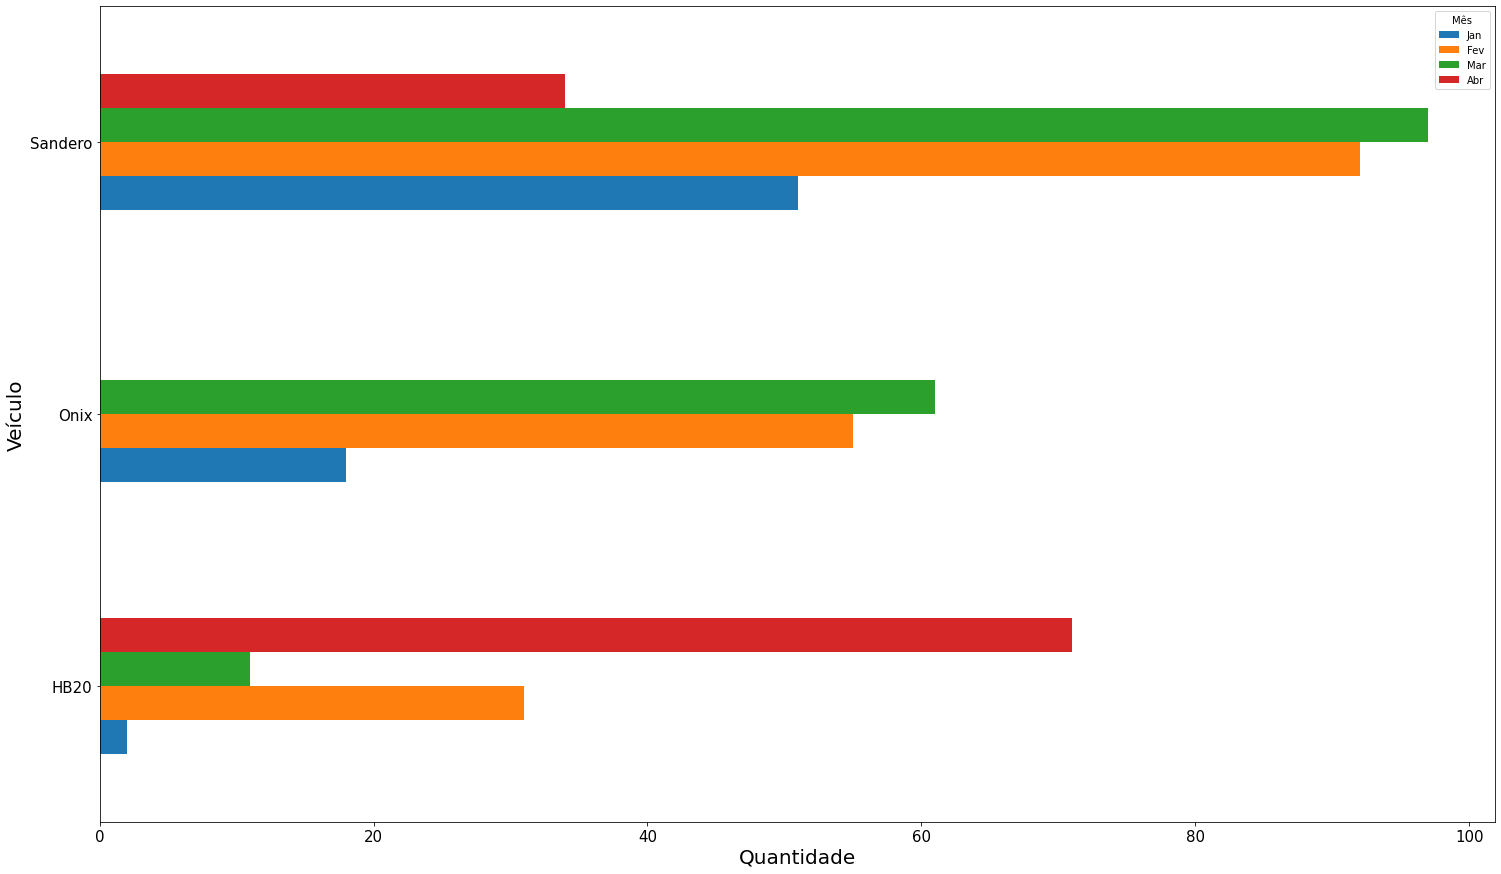

In [59]:
ax_bar = df_vendas.pivot(index='Veículo', columns='Mês', values='Quantidade').plot(kind='barh', figsize=(25,15), 
                                                                      fontsize=15)

ax_bar.set_xlabel('Quantidade', fontsize=20)
ax_bar.set_ylabel('Veículo', fontsize=20);

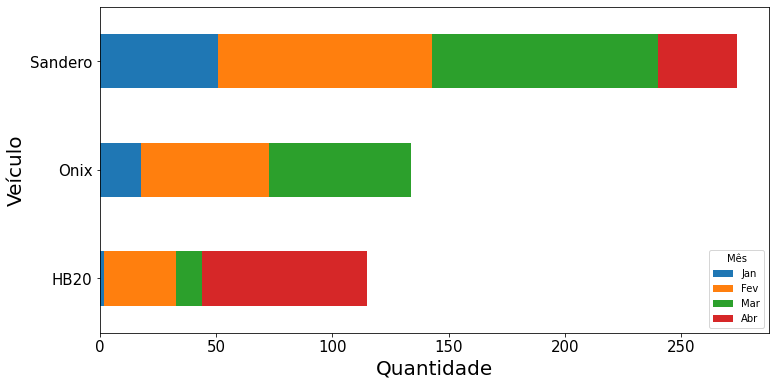

In [60]:
ax_bar = df_vendas.pivot(index='Veículo', columns='Mês', values='Quantidade').plot(kind='barh', figsize=(12,6), 
                         fontsize=15, stacked=True)

ax_bar.set_xlabel('Quantidade', fontsize=20)
ax_bar.set_ylabel('Veículo', fontsize=20);

In [87]:
df_pivotiado = df_vendas_pivot.reset_index()
df_pivotiado

Veículo,Mês,HB20,Onix,Sandero
0,Jan,2,18,51
1,Fev,31,55,92
2,Mar,11,61,97
3,Abr,71,0,34


In [88]:
# voltar do pivot
pd.melt(df_pivotiado, id_vars = "Mês", value_vars = ["HB20","Onix","Sandero"])

,Mês,Veículo,value
0,Jan,HB20,2
1,Fev,HB20,31
2,Mar,HB20,11
3,Abr,HB20,71
4,Jan,Onix,18
5,Fev,Onix,55
6,Mar,Onix,61
7,Abr,Onix,0
8,Jan,Sandero,51
9,Fev,Sandero,92
